State after transients: S=0.074184, I=0.003062, v=0.007353
Period T = 86.910000 days
Computed γ'(t) = F(γ(t)) along the limit cycle

Integrating adjoint equation for 10 periods
Total integration time: 869.10 days
Backward integration complete
Solution shape: (3, 100000)
Z_raw shape after extracting last period: (3, 10000)

Period T = 86.910000
Angular frequency ω = 2π/T = 0.072295

Before normalization:
  Z · γ' ranges from 2.435989e-02 to 2.461965e-02

After normalization:
  Z · γ' should equal 2π/T = 0.072295
  Z · γ' ranges from 0.072295 to 0.072295

PERIODICITY CHECK

Z(0) = [-3.859576, -88.846072, 0.057689]
Z(T) = [-3.859614, -88.703488, 0.057800]

Z(T) - Z(0) = [-3.781670e-05, 1.425843e-01, 1.104956e-04]
|Z(T) - Z(0)| = 1.425843e-01
✗ Z is NOT periodic — may need more periods!
Computed σ'(ξ(t)) along the limit cycle
  σ' ranges from 4.099675e-03 to 2.499996e-01
Created periodic interpolation for v(t)

Computed H(φ) at 200 points
  H ranges from -1.689428e-02 to 7.760446e-02

H(φ)

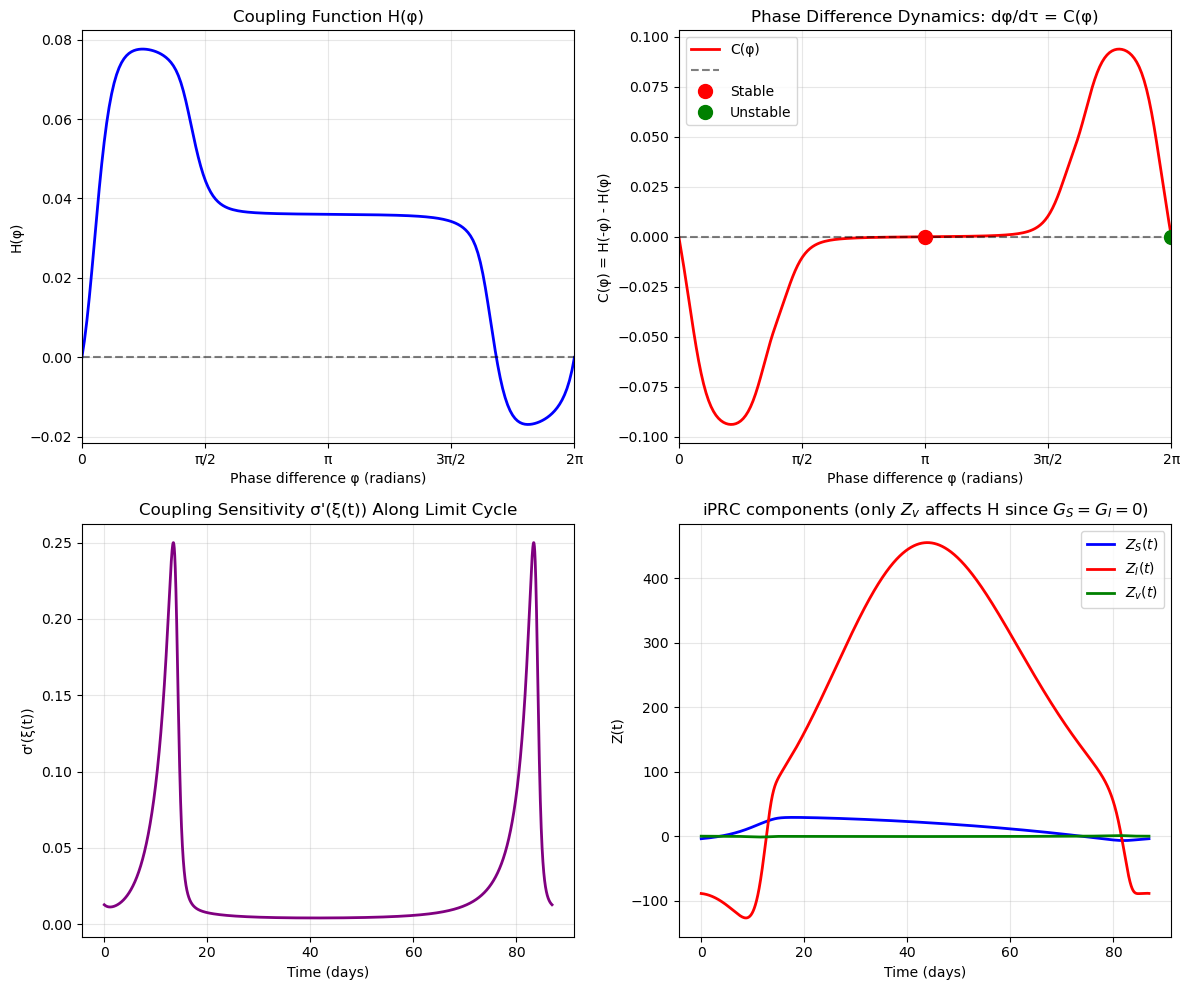


SUMMARY
Period T = 86.9100 days
ω = 2π/T = 0.072295 rad/day

Coupling function H(φ) computed
Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)

Phase-locked states occur where C(φ) = 0
  - Stable if C'(φ) < 0 (green dots)
  - Unstable if C'(φ) > 0 (red dots)


In [8]:

import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


# =============================================================================
# SYSTEM DEFINITION
# =============================================================================

def uncoupled_smooth_sirv(t, y, params):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']
    eta = params['eta']
    theta = params['theta']
    kappa = params['kappa']
    rho = params['rho']
    psi = params['psi']
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]


# =============================================================================
# PARAMETERS
# =============================================================================

params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 300,
    'rho': 0.01,
    'psi': 0.5
}

y0 = [0.49, 0.01, 0.01]  # Initial conditions [S0, I0, v0]


# =============================================================================
# STEP 1: INTEGRATE PAST TRANSIENTS
# =============================================================================

t_transient = 5000

sol_transient = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_transient],
    y0,
    method='RK45',
    rtol=1e-10,
    atol=1e-12
)

y_after_transient = sol_transient.y[:, -1]
print(f"State after transients: S={y_after_transient[0]:.6f}, "
      f"I={y_after_transient[1]:.6f}, v={y_after_transient[2]:.6f}")


# =============================================================================
# STEP 2: FIND THE PERIOD
# =============================================================================

t_cycle_search = 2000
dt = 0.01
t_eval = np.arange(0, t_cycle_search, dt)

sol_search = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_cycle_search],
    y_after_transient,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# Find peaks in I to determine period
I_data = sol_search.y[1, :]
peaks, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))

peak_times = sol_search.t[peaks]
periods = np.diff(peak_times)
T = np.mean(periods[-5:])  # Average of last 5 periods

print(f"Period T = {T:.6f} days")


# =============================================================================
# STEP 3: EXTRACT ONE COMPLETE CYCLE
# =============================================================================

# Start from a peak (phase = 0 at peak I)
start_idx = peaks[-2]
y_cycle_start = sol_search.y[:, start_idx]

# Integrate for exactly one period
n_points = 10000
t_cycle = np.linspace(0, T, n_points)

sol_cycle = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, T],
    y_cycle_start,
    method='RK45',
    t_eval=t_cycle,
    rtol=1e-12,
    atol=1e-14
)


# =============================================================================
# STEP 4: STORE THE LIMIT CYCLE AS Gamma
# =============================================================================

class Gamma:
    """
    Container for the limit cycle γ(t) = [S(t), I(t), v(t)]
    
    Usage:
        Gamma.t    - time array [0, T]
        Gamma.S    - S(t) along the cycle
        Gamma.I    - I(t) along the cycle
        Gamma.v    - v(t) along the cycle
        Gamma.T    - period
        Gamma.y    - full state array, shape (3, n_points)
    """
    t = sol_cycle.t
    S = sol_cycle.y[0, :]
    I = sol_cycle.y[1, :]
    v = sol_cycle.y[2, :]
    T = T
    y = sol_cycle.y  # [S, I, v] stacked


# =============================================================================
# COMPUTE THE JACOBIAN DF USING SYMPY
# =============================================================================

import sympy as sp

# Define symbolic variables
S_sym, I_sym, v_sym = sp.symbols('S I v')
alpha_sym, beta_sym, gamma_sym, eta_sym = sp.symbols('alpha beta gamma eta')
theta_sym, kappa_sym, rho_sym, psi_sym = sp.symbols('theta kappa rho psi')

# Define the vector field F = [F1, F2, F3]
F1 = alpha_sym*(psi_sym - S_sym - I_sym) - beta_sym*S_sym*(I_sym/psi_sym) - eta_sym*v_sym*S_sym
F2 = -gamma_sym*I_sym + beta_sym*S_sym*(I_sym/psi_sym)
F3 = -v_sym + 1/(1 + sp.exp(-kappa_sym*(beta_sym*I_sym/psi_sym - rho_sym - theta_sym*(1 - 2*v_sym))))

F = sp.Matrix([F1, F2, F3])
state = sp.Matrix([S_sym, I_sym, v_sym])

# Compute Jacobian symbolically
DF_symbolic = F.jacobian(state)


# Convert to numerical function
param_symbols = (alpha_sym, beta_sym, gamma_sym, eta_sym, theta_sym, kappa_sym, rho_sym, psi_sym)
all_symbols = (S_sym, I_sym, v_sym) + param_symbols

DF_func = sp.lambdify(all_symbols, DF_symbolic, modules='numpy')


def compute_DF(S, I, v, params):
    """
    Compute the Jacobian matrix DF at a point (S, I, v).
    
    Returns:
        DF : 3x3 numpy array
    """
    return np.array(DF_func(
        S, I, v,
        params['alpha'], params['beta'], params['gamma'], params['eta'],
        params['theta'], params['kappa'], params['rho'], params['psi']
    ))

# =============================================================================
# COMPUTE A(t) = DF(Gamma(t)) ALONG THE LIMIT CYCLE
# =============================================================================

n_points = len(Gamma.t)
A = np.zeros((n_points, 3, 3))

for i in range(n_points):
    A[i] = compute_DF(Gamma.S[i], Gamma.I[i], Gamma.v[i], params)
# =============================================================================
# COMPUTE Z(t) BY BACKWARD INTEGRATION OF THE ADJOINT EQUATION
# =============================================================================

from scipy.interpolate import interp1d

# -----------------------------------------------------------------------------
# Step 1: Compute γ'(t) = F(γ(t)) along the limit cycle
# -----------------------------------------------------------------------------

# γ'(t) is just the vector field evaluated along the cycle
Gamma_dot = np.zeros((3, n_points))
for i in range(n_points):
    Gamma_dot[:, i] = uncoupled_smooth_sirv(Gamma.t[i], Gamma.y[:, i], params)

# Store in Gamma for convenience
Gamma.S_dot = Gamma_dot[0, :]
Gamma.I_dot = Gamma_dot[1, :]
Gamma.v_dot = Gamma_dot[2, :]
Gamma.y_dot = Gamma_dot

print("Computed γ'(t) = F(γ(t)) along the limit cycle")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for A(t)
# -----------------------------------------------------------------------------

# A(t) is periodic with period T, so we extend it periodically
def A_periodic(t):
    """Return A(t mod T) for any t."""
    t_mod = np.mod(t, Gamma.T)
    # Find the index in Gamma.t closest to t_mod
    idx = np.searchsorted(Gamma.t, t_mod)
    if idx >= len(Gamma.t):
        idx = len(Gamma.t) - 1
    return A[idx]

# For smoother interpolation
A_interp_base = interp1d(Gamma.t, A, axis=0, kind='linear', fill_value='extrapolate')

def A_interp_periodic(t):
    """Periodic interpolation of A(t)."""
    t_mod = np.mod(t, Gamma.T)
    return A_interp_base(t_mod)


# -----------------------------------------------------------------------------
# Step 3: Define the adjoint equation dZ/dt = -A(t)^T @ Z
# -----------------------------------------------------------------------------

def adjoint_equation_reversed_periodic(s, Z, T):
    """
    Time-reversed adjoint equation for forward integration.
    
    s = total_time - t, so t = total_time - s
    But A(t) is periodic, so we use A(t mod T)
    
    dZ/ds = A(t)^T @ Z
    """
    t = s  # We'll integrate forward in s, which corresponds to backward in original t
    A_t = A_interp_periodic(T - (s % T))  # Map back to [0, T] for A
    return A_t.T @ Z


# -----------------------------------------------------------------------------
# Step 4: Backward integration for MULTIPLE PERIODS
# -----------------------------------------------------------------------------

n_periods = 10  # Integrate for 7 periods as Youngmin suggested
total_time = n_periods * Gamma.T

print(f"\nIntegrating adjoint equation for {n_periods} periods")
print(f"Total integration time: {total_time:.2f} days")

# Initial condition: random vector (will be normalized later)
Z_initial = np.array([1.0, 1.0, 1.0])

# Integrate for n_periods * T
n_points_total = n_points * n_periods
s_eval = np.linspace(0, total_time, n_points_total)

sol_adjoint = solve_ivp(
    lambda s, Z: adjoint_equation_reversed_periodic(s, Z, Gamma.T),
    [0, total_time],
    Z_initial,
    method='RK45',
    t_eval=s_eval,
    rtol=1e-10,
    atol=1e-12
)

print(f"Backward integration complete")
print(f"Solution shape: {sol_adjoint.y.shape}")

# Extract only the LAST period (this should be converged to the periodic orbit)
# The last period corresponds to s ∈ [(n_periods-1)*T, n_periods*T]
last_period_start_idx = (n_periods - 1) * n_points
Z_raw = sol_adjoint.y[:, last_period_start_idx:]

# Flip to get Z(t) with t from 0 to T
Z_raw = Z_raw[:, ::-1]

# Make sure we have exactly n_points
if Z_raw.shape[1] != n_points:
    # Interpolate to get exactly n_points
    t_raw = np.linspace(0, Gamma.T, Z_raw.shape[1])
    Z_raw_interp = np.zeros((3, n_points))
    for i in range(3):
        Z_raw_interp[i, :] = np.interp(Gamma.t, t_raw, Z_raw[i, :])
    Z_raw = Z_raw_interp

print(f"Z_raw shape after extracting last period: {Z_raw.shape}")


# -----------------------------------------------------------------------------
# Step 5: Normalize so that Z(t) · γ'(t) = 2π/T
# -----------------------------------------------------------------------------

omega = 2 * np.pi / Gamma.T  # angular frequency

# Compute Z · γ' at each point
Z_dot_Gamma_dot = np.sum(Z_raw * Gamma_dot, axis=0)

print(f"\nPeriod T = {Gamma.T:.6f}")
print(f"Angular frequency ω = 2π/T = {omega:.6f}")

print(f"\nBefore normalization:")
print(f"  Z · γ' ranges from {Z_dot_Gamma_dot.min():.6e} to {Z_dot_Gamma_dot.max():.6e}")

# Normalize: scale Z so that Z · γ' = 2π/T
Z_normalized = Z_raw * omega / Z_dot_Gamma_dot

# Verify normalization
Z_dot_Gamma_dot_check = np.sum(Z_normalized * Gamma_dot, axis=0)
print(f"\nAfter normalization:")
print(f"  Z · γ' should equal 2π/T = {omega:.6f}")
print(f"  Z · γ' ranges from {Z_dot_Gamma_dot_check.min():.6f} to {Z_dot_Gamma_dot_check.max():.6f}")


# -----------------------------------------------------------------------------
# Step 6: Verify periodicity: Z(T) should equal Z(0)
# -----------------------------------------------------------------------------

print("\n" + "="*50)
print("PERIODICITY CHECK")
print("="*50)
print(f"\nZ(0) = [{Z_normalized[0, 0]:.6f}, {Z_normalized[1, 0]:.6f}, {Z_normalized[2, 0]:.6f}]")
print(f"Z(T) = [{Z_normalized[0, -1]:.6f}, {Z_normalized[1, -1]:.6f}, {Z_normalized[2, -1]:.6f}]")

Z_diff = Z_normalized[:, -1] - Z_normalized[:, 0]
print(f"\nZ(T) - Z(0) = [{Z_diff[0]:.6e}, {Z_diff[1]:.6e}, {Z_diff[2]:.6e}]")
print(f"|Z(T) - Z(0)| = {np.linalg.norm(Z_diff):.6e}")

if np.linalg.norm(Z_diff) < 1e-3:
    print("✓ Z is periodic (error < 1e-3)")
else:
    print("✗ Z is NOT periodic — may need more periods!")


# -----------------------------------------------------------------------------
# Step 7: Store Z(t) in a clean container
# -----------------------------------------------------------------------------

class Z_solution:
    """
    Container for the adjoint solution Z(t) = [Z_S(t), Z_I(t), Z_v(t)]
    
    This is the infinitesimal Phase Response Curve (iPRC).
    
    Usage:
        Z.t    - time array [0, T]
        Z.S    - Z_S(t), sensitivity to perturbations in S
        Z.I    - Z_I(t), sensitivity to perturbations in I
        Z.v    - Z_v(t), sensitivity to perturbations in v
        Z.y    - full solution array, shape (3, n_points)
    """
    t = Gamma.t
    S = Z_normalized[0, :]
    I = Z_normalized[1, :]
    v = Z_normalized[2, :]
    y = Z_normalized
    T = Gamma.T

Z = Z_solution()
# =============================================================================
# COMPUTE THE COUPLING FUNCTION H(φ)
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Define the coupling function G(X1, X2)
# -----------------------------------------------------------------------------

def compute_sigma_prime_along_cycle(Gamma, params):
    """
    Compute σ'(ξ(t)) along the limit cycle, where:
        ξ(t) = κ(β I(t)/ψ - ρ - θ(1 - 2v(t)))
        σ'(ξ) = σ(ξ)(1 - σ(ξ))
    
    Returns:
        sigma_prime : array of σ'(ξ(t)) at each time point
    """
    kappa = params['kappa']
    beta = params['beta']
    psi = params['psi']
    rho = params['rho']
    theta = params['theta']
    
    # ξ(t) along the cycle
    xi = kappa * (beta * Gamma.I / psi - rho - theta * (1 - 2 * Gamma.v))
    
    # σ(ξ)
    sigma = 1 / (1 + np.exp(-xi))
    
    # σ'(ξ) = σ(1 - σ)
    sigma_prime = sigma * (1 - sigma)
    
    return sigma_prime


sigma_prime = compute_sigma_prime_along_cycle(Gamma, params)

print("Computed σ'(ξ(t)) along the limit cycle")
print(f"  σ' ranges from {sigma_prime.min():.6e} to {sigma_prime.max():.6e}")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for periodic extension
# -----------------------------------------------------------------------------

# We need v(t + φ) which may go beyond [0, T]
# Use periodic extension: v(t + T) = v(t)

# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for periodic extension
# -----------------------------------------------------------------------------

from scipy.interpolate import interp1d

def make_periodic_interp(t, y, T):
    """
    Create interpolation function with periodic extension.
    
    For any query time t_q, it returns y(t_q mod T).
    """
    # Remove the last point to avoid duplicate at t=0 and t=T
    # (since y(0) = y(T) for a periodic orbit)
    t_one_period = t[:-1]
    y_one_period = y[:-1]
    
    # Extend to cover [-T, 2T] for safe interpolation
    t_extended = np.concatenate([t_one_period - T, t_one_period, t_one_period + T])
    y_extended = np.concatenate([y_one_period, y_one_period, y_one_period])
    
    interp_func = interp1d(t_extended, y_extended, kind='cubic')
    
    def periodic_func(t_query):
        # Map to [0, T) range, then use interpolation
        t_mod = np.mod(t_query, T)
        return interp_func(t_mod)
    
    return periodic_func


v_interp = make_periodic_interp(Gamma.t, Gamma.v, Gamma.T)

print("Created periodic interpolation for v(t)")


# -----------------------------------------------------------------------------
# Step 3: Compute H(φ) for a range of φ values
# -----------------------------------------------------------------------------

def compute_H(phi, Gamma, Z, sigma_prime, v_interp, params):
    """
    Compute the coupling function H(φ) using numerical integration.
    
    H(φ) = (1/T) ∫₀ᵀ Z_v(t) · 2κθσ'(ξ(t)) · (v(t) - v(t+φ)) dt
    
    Parameters:
        phi : float, phase difference
        Gamma : limit cycle container
        Z : adjoint solution container
        sigma_prime : array, σ'(ξ(t)) along cycle
        v_interp : function, periodic interpolation of v
        params : dict, system parameters
    
    Returns:
        H : float, value of coupling function at φ
    """
    kappa = params['kappa']
    theta = params['theta']
    T = Gamma.T
    
    # v(t + φ) at each time point
    v_shifted = v_interp(Gamma.t + phi)
    
    # The integrand: Z_v(t) · -2κθσ'(ξ(t)) · (v(t) - v(t+φ))
    integrand = Z.v * (-2) * kappa * theta * sigma_prime * (Gamma.v - v_shifted)
    
    # Numerical integration using trapezoidal rule
    H = np.trapz(integrand, Gamma.t) / T
    
    return H


# Compute H(φ) for φ ∈ [0, 2π] (or equivalently [0, T] in time units)
n_phi = 200
phi_values = np.linspace(0, Gamma.T, n_phi)  # φ in time units [0, T]
H_values = np.zeros(n_phi)

for i, phi in enumerate(phi_values):
    H_values[i] = compute_H(phi, Gamma, Z, sigma_prime, v_interp, params)

print(f"\nComputed H(φ) at {n_phi} points")
print(f"  H ranges from {H_values.min():.6e} to {H_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 4: Store H(φ) in a container
# -----------------------------------------------------------------------------

class H_function:
    """
    Container for the coupling function H(φ).
    
    Usage:
        H.phi   - φ values in time units [0, T]
        H.theta - φ values in angle units [0, 2π]
        H.values - H(φ) at each point
        H.T     - period
    """
    phi = phi_values              # in time units
    theta = 2 * np.pi * phi_values / Gamma.T  # in angle units [0, 2π]
    values = H_values
    T = Gamma.T

H = H_function()

# Also create an interpolation function for H
H_interp = make_periodic_interp(H.phi, H.values, H.T)

print("\nH(φ) stored in H container")


# -----------------------------------------------------------------------------
# Step 5: Compute the odd part C(φ) = H(-φ) - H(φ) for phase difference dynamics
# -----------------------------------------------------------------------------

# For identical oscillators, phase difference evolves as:
# dφ/dτ = H(-φ) - H(φ) := C(φ)
# (Note: H(-φ) = H(T - φ) by periodicity)

C_values = np.zeros(n_phi)
for i, phi in enumerate(phi_values):
    H_minus_phi = compute_H(-phi, Gamma, Z, sigma_prime, v_interp, params)
    C_values[i] = H_minus_phi - H_values[i]

# Alternative using periodicity: H(-φ) = H(T - φ)
# C_values = H_interp(Gamma.T - phi_values) - H_values

print(f"\nComputed C(φ) = H(-φ) - H(φ)")
print(f"  C ranges from {C_values.min():.6e} to {C_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 6: Find fixed points (phase-locked states)
# -----------------------------------------------------------------------------

# Fixed points occur where C(φ) = 0
# Stable if C'(φ) < 0, unstable if C'(φ) > 0

# Find zero crossings
from scipy.interpolate import UnivariateSpline

# Create a smooth spline for C to find roots
C_spline = UnivariateSpline(phi_values, C_values, s=0)
C_derivative = C_spline.derivative()

# Find approximate zeros by looking for sign changes
sign_changes = np.where(np.diff(np.sign(C_values)))[0]

print("\n" + "="*50)
print("PHASE-LOCKED STATES")
print("="*50)

for idx in sign_changes:
    # Refine zero location
    from scipy.optimize import brentq
    phi_left = phi_values[idx]
    phi_right = phi_values[idx + 1]
    
    try:
        phi_zero = brentq(C_spline, phi_left, phi_right)
        C_prime_at_zero = C_derivative(phi_zero)
        stability = "STABLE" if C_prime_at_zero < 0 else "UNSTABLE"
        
        # Convert to angle
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        
        print(f"\n  φ = {phi_zero:.4f} days (θ = {theta_zero:.4f} rad = {np.degrees(theta_zero):.1f}°)")
        print(f"    C'(φ) = {C_prime_at_zero:.6e}")
        print(f"    {stability}")
    except:
        pass


# -----------------------------------------------------------------------------
# Step 7: Plot everything
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot H(φ)
ax1 = axes[0, 0]
ax1.plot(H.theta, H.values, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Phase difference φ (radians)')
ax1.set_ylabel('H(φ)')
ax1.set_title('Coupling Function H(φ)')
ax1.set_xlim([0, 2*np.pi])
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax1.grid(True, alpha=0.3)

# Plot C(φ) = H(-φ) - H(φ)
ax2 = axes[0, 1]
theta_values = 2 * np.pi * phi_values / Gamma.T
ax2.plot(theta_values, C_values, 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Phase difference φ (radians)')
ax2.set_ylabel('C(φ) = H(-φ) - H(φ)')
ax2.set_title('Phase Difference Dynamics: dφ/dτ = C(φ)')
ax2.set_xlim([0, 2*np.pi])
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax2.grid(True, alpha=0.3)

# Mark fixed points on C(φ)
for idx in sign_changes:
    try:
        phi_left = phi_values[idx]
        phi_right = phi_values[idx + 1]
        phi_zero = brentq(C_spline, phi_left, phi_right)
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        C_prime = C_derivative(phi_zero)
        color = 'go' if C_prime < 0 else 'ro'  # green = stable, red = unstable
        ax2.plot(theta_zero, 0, color, markersize=10)
    except:
        pass

ax2.legend(['C(φ)', '', 'Stable', 'Unstable'], loc='best')

# Plot σ'(ξ(t)) to show when coupling is active
ax3 = axes[1, 0]
ax3.plot(Gamma.t, sigma_prime, 'purple', linewidth=2)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel("σ'(ξ(t))")
ax3.set_title("Coupling Sensitivity σ'(ξ(t)) Along Limit Cycle")
ax3.grid(True, alpha=0.3)

# Plot all Z components
ax4 = axes[1, 1]
ax4.plot(Z.t, Z.S, 'b-', linewidth=2, label='$Z_S(t)$')
ax4.plot(Z.t, Z.I, 'r-', linewidth=2, label='$Z_I(t)$')
ax4.plot(Z.t, Z.v, 'g-', linewidth=2, label='$Z_v(t)$')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Z(t)')
ax4.set_title('iPRC components (only $Z_v$ affects H since $G_S = G_I = 0$)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('coupling_function_H.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Period T = {Gamma.T:.4f} days")
print(f"ω = 2π/T = {2*np.pi/Gamma.T:.6f} rad/day")
print(f"\nCoupling function H(φ) computed")
print(f"Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)")
print(f"\nPhase-locked states occur where C(φ) = 0")
print(f"  - Stable if C'(φ) < 0 (green dots)")
print(f"  - Unstable if C'(φ) > 0 (red dots)")

SCANNING FOR BIFURCATION POINT

Step 1: Coarse scan from κ = 350 to κ = 420
  Computing κ = 350.0 (1/8)...
    C'(π) = 4.537742e-06
  Computing κ = 360.0 (2/8)...
    C'(π) = 2.773728e-06
  Computing κ = 370.0 (3/8)...
    C'(π) = 1.452037e-06
  Computing κ = 380.0 (4/8)...
    C'(π) = 4.779845e-07
  Computing κ = 390.0 (5/8)...
    C'(π) = -2.243734e-07
  Computing κ = 400.0 (6/8)...
    C'(π) = -7.130892e-07
  Computing κ = 410.0 (7/8)...
    C'(π) = -1.038178e-06
  Computing κ = 420.0 (8/8)...
    C'(π) = -1.241053e-06


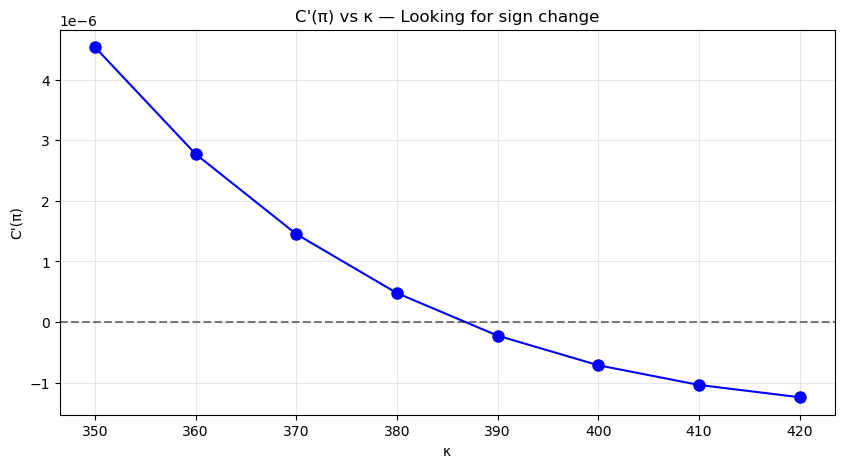


Sign change detected between κ = 380.0 and κ = 390.0

Step 2: Fine scan from κ = 380.0 to κ = 390.0
  Computing κ = 380.0 (1/10)...
    C'(π) = 4.779845e-07
  Computing κ = 381.1 (2/10)...
    C'(π) = 3.840582e-07
  Computing κ = 382.2 (3/10)...
    C'(π) = 3.012538e-07
  Computing κ = 383.3 (4/10)...
    C'(π) = 2.173500e-07
  Computing κ = 384.4 (5/10)...
    C'(π) = 1.363763e-07
  Computing κ = 385.6 (6/10)...
    C'(π) = 5.821458e-08
  Computing κ = 386.7 (7/10)...
    C'(π) = -1.365296e-08
  Computing κ = 387.8 (8/10)...
    C'(π) = -8.648265e-08
  Computing κ = 388.9 (9/10)...
    C'(π) = -1.567149e-07
  Computing κ = 390.0 (10/10)...
    C'(π) = -2.243734e-07

BIFURCATION POINT FOUND

κ* ≈ 386.46

At κ = 385.56: C'(π) = 5.821458e-08
At κ = 386.67: C'(π) = -1.365296e-08


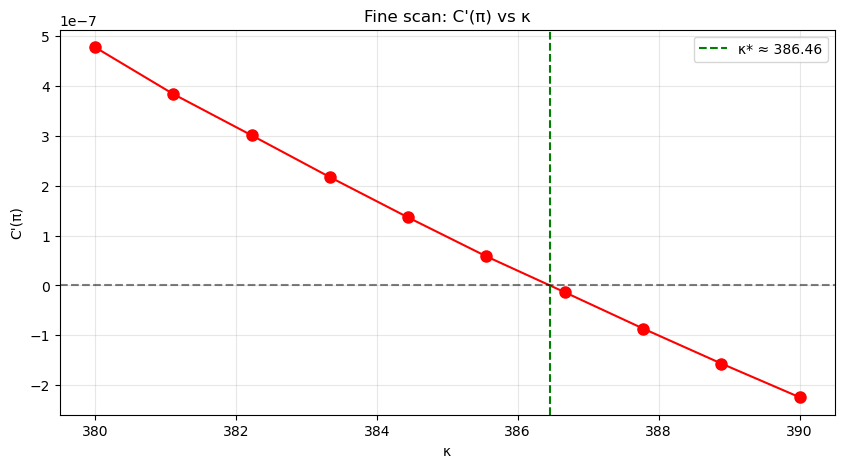

In [10]:
from scipy.optimize import brentq
from scipy.interpolate import UnivariateSpline

def compute_C_prime_at_pi(kappa_val):
    """
    For a given kappa, compute the full analysis and return C'(π).
    This is the quantity that changes sign at the bifurcation.
    """
    
    params_local = {
        'alpha': 0.01, 'beta': 0.5, 'gamma': 1/7, 'eta': 1/7,
        'theta': 0.01, 'kappa': kappa_val, 'rho': 0.01, 'psi': 0.5
    }
    
    y0_local = [0.49, 0.01, 0.01]
    
    # Step 1: Find limit cycle
    sol_transient = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_local),
        [0, 5000], y0_local, method='RK45', rtol=1e-10, atol=1e-12
    )
    y_after_transient = sol_transient.y[:, -1]
    
    dt = 0.01
    t_eval_search = np.arange(0, 2000, dt)
    sol_search = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_local),
        [0, 2000], y_after_transient, method='RK45', t_eval=t_eval_search, rtol=1e-10, atol=1e-12
    )
    
    I_data = sol_search.y[1, :]
    peaks_local, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))
    peak_times = sol_search.t[peaks_local]
    T_local = np.mean(np.diff(peak_times[-5:]))
    
    start_idx = peaks_local[-2]
    y_cycle_start = sol_search.y[:, start_idx]
    
    n_pts = 1000
    t_cycle_local = np.linspace(0, T_local, n_pts)
    sol_cycle = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_local),
        [0, T_local], y_cycle_start, method='RK45', t_eval=t_cycle_local, rtol=1e-12, atol=1e-14
    )
    
    Gamma_t_local = sol_cycle.t
    Gamma_y_local = sol_cycle.y
    Gamma_I_local = sol_cycle.y[1, :]
    Gamma_v_local = sol_cycle.y[2, :]
    
    # Step 2: Compute Jacobian A(t)
    A_local = np.zeros((n_pts, 3, 3))
    for i in range(n_pts):
        A_local[i] = compute_DF(Gamma_y_local[0, i], Gamma_y_local[1, i], Gamma_y_local[2, i], params_local)
    
    # Step 3: Compute gamma_dot
    Gamma_dot_local = np.zeros((3, n_pts))
    for i in range(n_pts):
        Gamma_dot_local[:, i] = uncoupled_smooth_sirv(Gamma_t_local[i], Gamma_y_local[:, i], params_local)
    
    # Step 4: Backward integration for Z
    A_interp_local = interp1d(Gamma_t_local, A_local, axis=0, kind='linear', fill_value='extrapolate')
    
    def A_interp_periodic_local(t):
        t_mod = np.mod(t, T_local)
        return A_interp_local(t_mod)
    
    def adjoint_reversed_local(s, Z):
        A_t = A_interp_periodic_local(T_local - (s % T_local))
        return A_t.T @ Z
    
    n_periods_local = 7
    total_time_local = n_periods_local * T_local
    Z_initial_local = np.array([1.0, 1.0, 1.0])
    n_pts_total = n_pts * n_periods_local
    s_eval_local = np.linspace(0, total_time_local, n_pts_total)
    
    sol_adjoint = solve_ivp(
        adjoint_reversed_local,
        [0, total_time_local], Z_initial_local, method='RK45', t_eval=s_eval_local, rtol=1e-10, atol=1e-12
    )
    
    last_period_idx = (n_periods_local - 1) * n_pts
    Z_raw_local = sol_adjoint.y[:, last_period_idx:]
    Z_raw_local = Z_raw_local[:, ::-1]
    
    if Z_raw_local.shape[1] != n_pts:
        t_raw = np.linspace(0, T_local, Z_raw_local.shape[1])
        Z_raw_interp = np.zeros((3, n_pts))
        for i in range(3):
            Z_raw_interp[i, :] = np.interp(Gamma_t_local, t_raw, Z_raw_local[i, :])
        Z_raw_local = Z_raw_interp
    
    omega_local = 2 * np.pi / T_local
    Z_dot_Gamma_dot = np.sum(Z_raw_local * Gamma_dot_local, axis=0)
    Z_normalized_local = Z_raw_local * omega_local / Z_dot_Gamma_dot
    Z_v_local = Z_normalized_local[2, :]
    
    # Step 5: Compute sigma_prime
    kappa = params_local['kappa']
    beta = params_local['beta']
    psi = params_local['psi']
    rho = params_local['rho']
    theta = params_local['theta']
    
    xi = kappa * (beta * Gamma_I_local / psi - rho - theta * (1 - 2 * Gamma_v_local))
    sigma = 1 / (1 + np.exp(-xi))
    sigma_prime_local = sigma * (1 - sigma)
    
    # Step 6: Create periodic interpolation for v
    v_interp_local = make_periodic_interp(Gamma_t_local, Gamma_v_local, T_local)
    
    # Step 7: Compute H(phi) and C(phi)
    def compute_H_local(phi):
        v_shifted = v_interp_local(Gamma_t_local + phi)
        integrand = Z_v_local * (-2) * kappa * theta * sigma_prime_local * (Gamma_v_local - v_shifted)
        return np.trapz(integrand, Gamma_t_local) / T_local
    
    n_phi_local = 200
    phi_vals = np.linspace(0, T_local, n_phi_local)
    H_vals = np.array([compute_H_local(phi) for phi in phi_vals])
    C_vals = np.array([compute_H_local(-phi) - compute_H_local(phi) for phi in phi_vals])
    
    # Step 8: Compute C'(pi)
    C_spline_local = UnivariateSpline(phi_vals, C_vals, s=0)
    C_deriv_local = C_spline_local.derivative()
    
    phi_pi = T_local / 2
    C_prime_at_pi = float(C_deriv_local(phi_pi))
    
    return C_prime_at_pi, T_local


def scan_kappa_for_bifurcation(kappa_min, kappa_max, n_kappa):
    """
    Scan a range of kappa values and compute C'(π) for each.
    """
    kappa_values = np.linspace(kappa_min, kappa_max, n_kappa)
    C_prime_values = []
    T_values = []
    
    for i, kappa_val in enumerate(kappa_values):
        print(f"  Computing κ = {kappa_val:.1f} ({i+1}/{n_kappa})...")
        C_prime, T_val = compute_C_prime_at_pi(kappa_val)
        C_prime_values.append(C_prime)
        T_values.append(T_val)
        print(f"    C'(π) = {C_prime:.6e}")
    
    return kappa_values, np.array(C_prime_values), np.array(T_values)

print("="*60)
print("SCANNING FOR BIFURCATION POINT")
print("="*60)

# Coarse scan first
print("\nStep 1: Coarse scan from κ = 350 to κ = 420")
kappa_coarse, C_prime_coarse, T_coarse = scan_kappa_for_bifurcation(350, 420, 8)

# Plot the coarse scan
plt.figure(figsize=(10, 5))
plt.plot(kappa_coarse, C_prime_coarse, 'bo-', markersize=8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('κ')
plt.ylabel("C'(π)")
plt.title("C'(π) vs κ — Looking for sign change")
plt.grid(True, alpha=0.3)
plt.show()

# Find where sign change occurs
sign_changes_kappa = np.where(np.diff(np.sign(C_prime_coarse)))[0]

if len(sign_changes_kappa) > 0:
    idx = sign_changes_kappa[0]
    kappa_left = kappa_coarse[idx]
    kappa_right = kappa_coarse[idx + 1]
    print(f"\nSign change detected between κ = {kappa_left:.1f} and κ = {kappa_right:.1f}")
    
    # Fine scan
    print(f"\nStep 2: Fine scan from κ = {kappa_left:.1f} to κ = {kappa_right:.1f}")
    kappa_fine, C_prime_fine, T_fine = scan_kappa_for_bifurcation(kappa_left, kappa_right, 10)
    
    # Find more precise location
    sign_changes_fine = np.where(np.diff(np.sign(C_prime_fine)))[0]
    
    if len(sign_changes_fine) > 0:
        idx_fine = sign_changes_fine[0]
        kappa_a = kappa_fine[idx_fine]
        kappa_b = kappa_fine[idx_fine + 1]
        C_prime_a = C_prime_fine[idx_fine]
        C_prime_b = C_prime_fine[idx_fine + 1]
        
        # Linear interpolation to estimate kappa*
        kappa_star_estimate = kappa_a - C_prime_a * (kappa_b - kappa_a) / (C_prime_b - C_prime_a)
        
        print(f"\n{'='*60}")
        print(f"BIFURCATION POINT FOUND")
        print(f"{'='*60}")
        print(f"\nκ* ≈ {kappa_star_estimate:.2f}")
        print(f"\nAt κ = {kappa_a:.2f}: C'(π) = {C_prime_a:.6e}")
        print(f"At κ = {kappa_b:.2f}: C'(π) = {C_prime_b:.6e}")
        
        # Plot fine scan
        plt.figure(figsize=(10, 5))
        plt.plot(kappa_fine, C_prime_fine, 'ro-', markersize=8)
        plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        plt.axvline(x=kappa_star_estimate, color='g', linestyle='--', label=f'κ* ≈ {kappa_star_estimate:.2f}')
        plt.xlabel('κ')
        plt.ylabel("C'(π)")
        plt.title("Fine scan: C'(π) vs κ")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
else:
    print("\nNo sign change detected in this range. Try a different range.")

TAYLOR SERIES ANALYSIS AT κ* = 386.5

Computing full analysis (this may take a minute)...
  Period T = 91.1175 days
  Computed H(φ) and C(φ)

TAYLOR SERIES COEFFICIENTS AT φ = π

φ_π = T/2 = 45.5588 days (corresponds to θ = π radians)

C(φ) ≈ C(π) + C'(π)(φ-π) + C''(π)(φ-π)²/2 + C'''(π)(φ-π)³/6 + ...

  C(π)    = -1.741074e-24
  C'(π)   = 5.439010e-09
  C''(π)  = 2.518765e-22
  C'''(π) = 6.147716e-08

INTERPRETATION

1. C(π) ≈ 0?
   Value: -1.741074e-24
   ✓ Yes — π is a fixed point

2. C'(π) ≈ 0?
   Value: 5.439010e-09
   ✓ Yes — this confirms we are at the bifurcation point

3. C''(π) ≈ 0?
   Value: 2.518765e-22
   ✓ Yes — as expected by symmetry (C is odd around π)

4. C'''(π) ≠ 0?
   Value: 6.147716e-08
   ✓ Yes — this is the leading nonlinear term
   Since C'''(π) > 0, this indicates a SUPERCRITICAL pitchfork

FIXED POINTS AT κ* = 386.5

  φ = 0.0°
    C'(φ) = -1.424251e-02
    STABLE

  φ = 180.0°
    C'(φ) = 5.439010e-09
    UNSTABLE

  φ = 360.0°
    C'(φ) = -1.424251e-02
    S

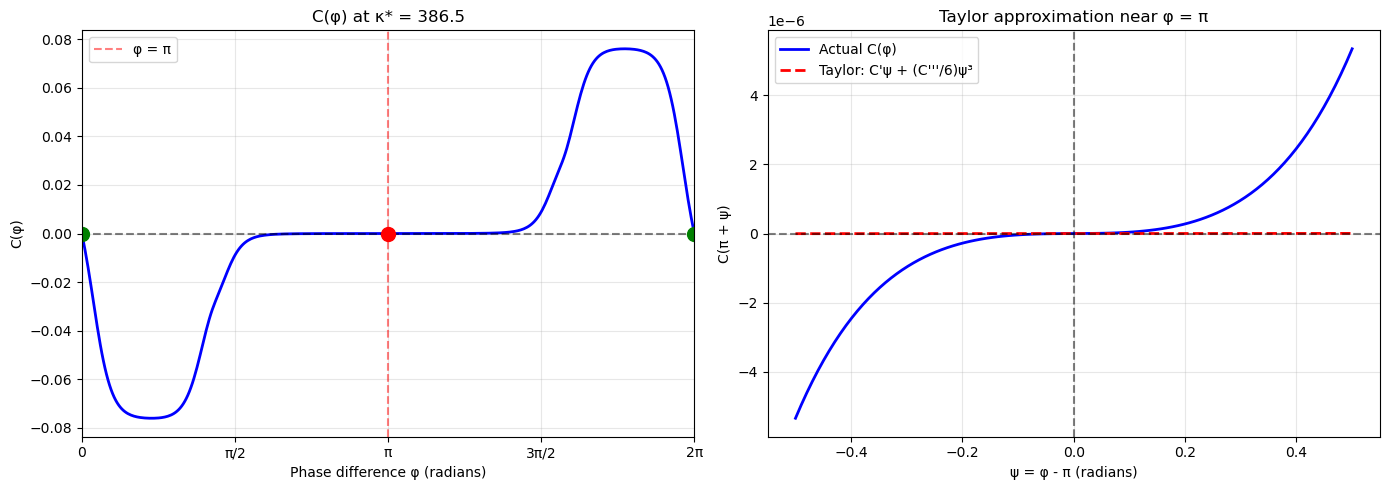


Figure saved as 'taylor_analysis_at_bifurcation.png'


In [12]:
# =============================================================================
# TAYLOR SERIES ANALYSIS AT THE BIFURCATION POINT κ* = 386.5
# =============================================================================

kappa_star = 386.5

print("="*60)
print(f"TAYLOR SERIES ANALYSIS AT κ* = {kappa_star}")
print("="*60)
print("\nComputing full analysis (this may take a minute)...")

# -----------------------------------------------------------------------------
# Step 1: Run the full pipeline for kappa_star
# -----------------------------------------------------------------------------

params_star = {
    'alpha': 0.01, 'beta': 0.5, 'gamma': 1/7, 'eta': 1/7,
    'theta': 0.01, 'kappa': kappa_star, 'rho': 0.01, 'psi': 0.5
}

y0_local = [0.49, 0.01, 0.01]

# Find limit cycle
sol_transient = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params_star),
    [0, 5000], y0_local, method='RK45', rtol=1e-10, atol=1e-12
)
y_after_transient = sol_transient.y[:, -1]

dt = 0.01
t_eval_search = np.arange(0, 2000, dt)
sol_search = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params_star),
    [0, 2000], y_after_transient, method='RK45', t_eval=t_eval_search, rtol=1e-10, atol=1e-12
)

I_data = sol_search.y[1, :]
peaks_local, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))
peak_times = sol_search.t[peaks_local]
T_star = np.mean(np.diff(peak_times[-5:]))

start_idx = peaks_local[-2]
y_cycle_start = sol_search.y[:, start_idx]

n_pts = 2000  # More points for better derivative accuracy
t_cycle_local = np.linspace(0, T_star, n_pts)
sol_cycle = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params_star),
    [0, T_star], y_cycle_start, method='RK45', t_eval=t_cycle_local, rtol=1e-12, atol=1e-14
)

Gamma_t_star = sol_cycle.t
Gamma_y_star = sol_cycle.y
Gamma_I_star = sol_cycle.y[1, :]
Gamma_v_star = sol_cycle.y[2, :]

print(f"  Period T = {T_star:.4f} days")

# Compute Jacobian A(t)
A_star = np.zeros((n_pts, 3, 3))
for i in range(n_pts):
    A_star[i] = compute_DF(Gamma_y_star[0, i], Gamma_y_star[1, i], Gamma_y_star[2, i], params_star)

# Compute gamma_dot
Gamma_dot_star = np.zeros((3, n_pts))
for i in range(n_pts):
    Gamma_dot_star[:, i] = uncoupled_smooth_sirv(Gamma_t_star[i], Gamma_y_star[:, i], params_star)

# Backward integration for Z
A_interp_star = interp1d(Gamma_t_star, A_star, axis=0, kind='linear', fill_value='extrapolate')

def A_interp_periodic_star(t):
    t_mod = np.mod(t, T_star)
    return A_interp_star(t_mod)

def adjoint_reversed_star(s, Z):
    A_t = A_interp_periodic_star(T_star - (s % T_star))
    return A_t.T @ Z

n_periods_local = 10
total_time_local = n_periods_local * T_star
Z_initial_local = np.array([1.0, 1.0, 1.0])
n_pts_total = n_pts * n_periods_local
s_eval_local = np.linspace(0, total_time_local, n_pts_total)

sol_adjoint = solve_ivp(
    adjoint_reversed_star,
    [0, total_time_local], Z_initial_local, method='RK45', t_eval=s_eval_local, rtol=1e-10, atol=1e-12
)

last_period_idx = (n_periods_local - 1) * n_pts
Z_raw_star = sol_adjoint.y[:, last_period_idx:]
Z_raw_star = Z_raw_star[:, ::-1]

if Z_raw_star.shape[1] != n_pts:
    t_raw = np.linspace(0, T_star, Z_raw_star.shape[1])
    Z_raw_interp = np.zeros((3, n_pts))
    for i in range(3):
        Z_raw_interp[i, :] = np.interp(Gamma_t_star, t_raw, Z_raw_star[i, :])
    Z_raw_star = Z_raw_interp

omega_star = 2 * np.pi / T_star
Z_dot_Gamma_dot = np.sum(Z_raw_star * Gamma_dot_star, axis=0)
Z_normalized_star = Z_raw_star * omega_star / Z_dot_Gamma_dot
Z_v_star = Z_normalized_star[2, :]

# Compute sigma_prime
kappa = params_star['kappa']
beta = params_star['beta']
psi = params_star['psi']
rho = params_star['rho']
theta = params_star['theta']

xi = kappa * (beta * Gamma_I_star / psi - rho - theta * (1 - 2 * Gamma_v_star))
sigma = 1 / (1 + np.exp(-xi))
sigma_prime_star = sigma * (1 - sigma)

# Create periodic interpolation for v
v_interp_star = make_periodic_interp(Gamma_t_star, Gamma_v_star, T_star)

# Compute H(phi) and C(phi)
def compute_H_star(phi):
    v_shifted = v_interp_star(Gamma_t_star + phi)
    integrand = Z_v_star * (-2) * kappa * theta * sigma_prime_star * (Gamma_v_star - v_shifted)
    return np.trapz(integrand, Gamma_t_star) / T_star

n_phi = 400  # More points for better derivative accuracy
phi_vals = np.linspace(0, T_star, n_phi)
H_vals = np.array([compute_H_star(phi) for phi in phi_vals])
C_vals = np.array([compute_H_star(-phi) - compute_H_star(phi) for phi in phi_vals])

print("  Computed H(φ) and C(φ)")

# -----------------------------------------------------------------------------
# Step 2: Compute Taylor series coefficients at φ = π
# -----------------------------------------------------------------------------

C_spline_star = UnivariateSpline(phi_vals, C_vals, s=0)

# Compute derivatives
C_deriv_1 = C_spline_star.derivative(n=1)
C_deriv_2 = C_spline_star.derivative(n=2)
C_deriv_3 = C_spline_star.derivative(n=3)

phi_pi = T_star / 2  # φ = π in time units

C_at_pi = float(C_spline_star(phi_pi))
C_1 = float(C_deriv_1(phi_pi))
C_2 = float(C_deriv_2(phi_pi))
C_3 = float(C_deriv_3(phi_pi))

print(f"\n{'='*60}")
print("TAYLOR SERIES COEFFICIENTS AT φ = π")
print(f"{'='*60}")
print(f"\nφ_π = T/2 = {phi_pi:.4f} days (corresponds to θ = π radians)")
print(f"\nC(φ) ≈ C(π) + C'(π)(φ-π) + C''(π)(φ-π)²/2 + C'''(π)(φ-π)³/6 + ...")
print(f"\n  C(π)    = {C_at_pi:.6e}")
print(f"  C'(π)   = {C_1:.6e}")
print(f"  C''(π)  = {C_2:.6e}")
print(f"  C'''(π) = {C_3:.6e}")

print(f"\n{'='*60}")
print("INTERPRETATION")
print(f"{'='*60}")

print(f"\n1. C(π) ≈ 0?")
print(f"   Value: {C_at_pi:.6e}")
print(f"   {'✓ Yes — π is a fixed point' if abs(C_at_pi) < 1e-6 else '✗ Not quite zero'}")

print(f"\n2. C'(π) ≈ 0?")
print(f"   Value: {C_1:.6e}")
print(f"   {'✓ Yes — this confirms we are at the bifurcation point' if abs(C_1) < 1e-6 else '✗ Not zero — adjust κ*'}")

print(f"\n3. C''(π) ≈ 0?")
print(f"   Value: {C_2:.6e}")
print(f"   {'✓ Yes — as expected by symmetry (C is odd around π)' if abs(C_2) < 1e-6 else '✗ Should be zero by symmetry'}")

print(f"\n4. C'''(π) ≠ 0?")
print(f"   Value: {C_3:.6e}")
if abs(C_3) > 1e-10:
    print(f"   ✓ Yes — this is the leading nonlinear term")
    if C_3 > 0:
        print(f"   Since C'''(π) > 0, this indicates a SUPERCRITICAL pitchfork")
    else:
        print(f"   Since C'''(π) < 0, this indicates a SUBCRITICAL pitchfork")
else:
    print(f"   ✗ Too close to zero — need to check higher derivatives")

# -----------------------------------------------------------------------------
# Step 3: Find fixed points and their stability
# -----------------------------------------------------------------------------

print(f"\n{'='*60}")
print("FIXED POINTS AT κ* = {:.1f}".format(kappa_star))
print(f"{'='*60}")

sign_changes = np.where(np.diff(np.sign(C_vals)))[0]
fixed_points = []

for idx in sign_changes:
    phi_left = phi_vals[idx]
    phi_right = phi_vals[idx + 1]
    try:
        phi_zero = brentq(C_spline_star, phi_left, phi_right)
        C_prime = float(C_deriv_1(phi_zero))
        theta_zero = 2 * np.pi * phi_zero / T_star
        stability = "STABLE" if C_prime < 0 else "UNSTABLE"
        fixed_points.append({
            'phi_time': phi_zero,
            'theta_rad': theta_zero,
            'theta_deg': np.degrees(theta_zero),
            'C_prime': C_prime,
            'stability': stability
        })
    except:
        pass

for fp in fixed_points:
    print(f"\n  φ = {fp['theta_deg']:.1f}°")
    print(f"    C'(φ) = {fp['C_prime']:.6e}")
    print(f"    {fp['stability']}")

# -----------------------------------------------------------------------------
# Step 4: Compute rate of change dC'(π)/dκ
# -----------------------------------------------------------------------------

print(f"\n{'='*60}")
print("RATE OF CHANGE: dC'(π)/dκ")
print(f"{'='*60}")

delta_kappa = 2.0
kappa_minus = kappa_star - delta_kappa
kappa_plus = kappa_star + delta_kappa

print(f"\nComputing C'(π) at κ = {kappa_minus} and κ = {kappa_plus}...")

C_prime_minus, _ = compute_C_prime_at_pi(kappa_minus)
C_prime_plus, _ = compute_C_prime_at_pi(kappa_plus)

a = (C_prime_plus - C_prime_minus) / (2 * delta_kappa)

print(f"\n  C'(π) at κ = {kappa_minus}: {C_prime_minus:.6e}")
print(f"  C'(π) at κ = {kappa_plus}: {C_prime_plus:.6e}")
print(f"\n  a = dC'(π)/dκ ≈ {a:.6e}")

# -----------------------------------------------------------------------------
# Step 5: Summary of bifurcation analysis
# -----------------------------------------------------------------------------

print(f"\n{'='*60}")
print("SUMMARY: PITCHFORK BIFURCATION ANALYSIS")
print(f"{'='*60}")

print(f"\nNear φ = π, the dynamics are approximately:")
print(f"  ψ̇ = a(κ - κ*)ψ + (C'''(π)/6)ψ³")
print(f"\nwhere ψ = φ - π")

print(f"\nParameter values:")
print(f"  κ* = {kappa_star}")
print(f"  a = dC'(π)/dκ = {a:.6e}")
print(f"  b = C'''(π)/6 = {C_3/6:.6e}")

print(f"\nBifurcation type:")
if a < 0 and C_3 > 0:
    print(f"  a < 0 and C'''(π) > 0 → SUPERCRITICAL PITCHFORK")
    print(f"\n  For κ < κ*: π is unstable, no other nearby fixed points")
    print(f"  For κ > κ*: π is stable, two unstable fixed points appear at ψ = ±√(-a(κ-κ*)/b)")
elif a > 0 and C_3 < 0:
    print(f"  a > 0 and C'''(π) < 0 → SUPERCRITICAL PITCHFORK")
    print(f"\n  For κ > κ*: π is unstable, no other nearby fixed points")
    print(f"  For κ < κ*: π is stable, two unstable fixed points appear")
elif a < 0 and C_3 < 0:
    print(f"  a < 0 and C'''(π) < 0 → SUBCRITICAL PITCHFORK")
elif a > 0 and C_3 > 0:
    print(f"  a > 0 and C'''(π) > 0 → SUBCRITICAL PITCHFORK")

# -----------------------------------------------------------------------------
# Step 6: Plot C(φ) near π
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot full C(φ)
theta_vals = 2 * np.pi * phi_vals / T_star
ax1 = axes[0]
ax1.plot(theta_vals, C_vals, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.axvline(x=np.pi, color='r', linestyle='--', alpha=0.5, label='φ = π')
for fp in fixed_points:
    color = 'go' if fp['stability'] == 'STABLE' else 'ro'
    ax1.plot(fp['theta_rad'], 0, color, markersize=10)
ax1.set_xlabel('Phase difference φ (radians)')
ax1.set_ylabel('C(φ)')
ax1.set_title(f'C(φ) at κ* = {kappa_star}')
ax1.set_xlim([0, 2*np.pi])
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot Taylor approximation near π
ax2 = axes[1]
psi_range = np.linspace(-0.5, 0.5, 100)  # ψ = φ - π in radians (scaled)
phi_range = phi_pi + psi_range * T_star / (2*np.pi)  # convert to time units

C_actual = np.array([float(C_spline_star(phi)) for phi in phi_range])
C_taylor = C_at_pi + C_1 * psi_range + (C_3/6) * psi_range**3  # C_2 ≈ 0

ax2.plot(psi_range, C_actual, 'b-', linewidth=2, label='Actual C(φ)')
ax2.plot(psi_range, C_taylor, 'r--', linewidth=2, label='Taylor: C\'ψ + (C\'\'\'/6)ψ³')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('ψ = φ - π (radians)')
ax2.set_ylabel('C(π + ψ)')
ax2.set_title('Taylor approximation near φ = π')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('taylor_analysis_at_bifurcation.png', dpi=150)
plt.show()

print(f"\nFigure saved as 'taylor_analysis_at_bifurcation.png'")

## how accurate are my predicted new fixed points?

In [20]:
# =============================================================================
# TEST: PREDICTED VS ACTUAL FIXED POINT LOCATIONS (CORRECTED)
# =============================================================================

print("="*60)
print("TESTING TAYLOR PREDICTION FOR NEW FIXED POINTS")
print("="*60)

# Given values
kappa_star = 386.5
a = -6.703483e-08
b = 1.024619e-08

print(f"\nGiven:")
print(f"  κ* = {kappa_star}")
print(f"  a = {a:.6e}")
print(f"  b = {b:.6e}")

# Test kappa values
kappa_test_values = [386.6, 386.7, 386.8, 386.9, 387.0]

print(f"\n{'='*60}")
print("FINDING ACTUAL FIXED POINTS NUMERICALLY")
print(f"{'='*60}")

for kappa_test in kappa_test_values:
    k = kappa_test - kappa_star
    
    # Predicted psi (in time units, since a and b are in time units)
    psi_predicted_time = np.sqrt(-a * k / b)
    
    # Run simulation to get C(phi)
    params_test = {
        'alpha': 0.01, 'beta': 0.5, 'gamma': 1/7, 'eta': 1/7,
        'theta': 0.01, 'kappa': kappa_test, 'rho': 0.01, 'psi': 0.5
    }
    
    y0_local = [0.49, 0.01, 0.01]
    
    # Find limit cycle
    sol_transient = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, 5000], y0_local, method='RK45', rtol=1e-10, atol=1e-12
    )
    y_after = sol_transient.y[:, -1]
    
    dt = 0.01
    t_eval_search = np.arange(0, 2000, dt)
    sol_search = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, 2000], y_after, method='RK45', t_eval=t_eval_search, rtol=1e-10, atol=1e-12
    )
    
    I_data = sol_search.y[1, :]
    peaks_test, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))
    T_test = np.mean(np.diff(sol_search.t[peaks_test][-5:]))
    
    start_idx = peaks_test[-2]
    y_cycle_start = sol_search.y[:, start_idx]
    
    n_pts = 1000
    t_cycle = np.linspace(0, T_test, n_pts)
    sol_cycle = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, T_test], y_cycle_start, method='RK45', t_eval=t_cycle, rtol=1e-12, atol=1e-14
    )
    
    Gamma_t = sol_cycle.t
    Gamma_y = sol_cycle.y
    Gamma_I = sol_cycle.y[1, :]
    Gamma_v = sol_cycle.y[2, :]
    
    # Compute Z (abbreviated version)
    A_test = np.zeros((n_pts, 3, 3))
    for i in range(n_pts):
        A_test[i] = compute_DF(Gamma_y[0, i], Gamma_y[1, i], Gamma_y[2, i], params_test)
    
    Gamma_dot = np.zeros((3, n_pts))
    for i in range(n_pts):
        Gamma_dot[:, i] = uncoupled_smooth_sirv(Gamma_t[i], Gamma_y[:, i], params_test)
    
    A_interp = interp1d(Gamma_t, A_test, axis=0, kind='linear', fill_value='extrapolate')
    
    def adjoint_reversed(s, Z):
        A_t = A_interp(np.mod(T_test - (s % T_test), T_test))
        return A_t.T @ Z
    
    n_periods = 7
    total_time = n_periods * T_test
    s_eval = np.linspace(0, total_time, n_pts * n_periods)
    
    sol_adjoint = solve_ivp(
        adjoint_reversed,
        [0, total_time], np.array([1.0, 1.0, 1.0]), method='RK45', t_eval=s_eval, rtol=1e-10, atol=1e-12
    )
    
    last_idx = (n_periods - 1) * n_pts
    Z_raw = sol_adjoint.y[:, last_idx:]
    Z_raw = Z_raw[:, ::-1]
    
    if Z_raw.shape[1] != n_pts:
        t_raw = np.linspace(0, T_test, Z_raw.shape[1])
        Z_interp = np.zeros((3, n_pts))
        for i in range(3):
            Z_interp[i, :] = np.interp(Gamma_t, t_raw, Z_raw[i, :])
        Z_raw = Z_interp
    
    omega = 2 * np.pi / T_test
    Z_dot_Gamma_dot = np.sum(Z_raw * Gamma_dot, axis=0)
    Z_normalized = Z_raw * omega / Z_dot_Gamma_dot
    Z_v = Z_normalized[2, :]
    
    # Compute sigma_prime
    beta = params_test['beta']
    psi_param = params_test['psi']
    rho = params_test['rho']
    theta = params_test['theta']
    
    xi = kappa_test * (beta * Gamma_I / psi_param - rho - theta * (1 - 2 * Gamma_v))
    sigma = 1 / (1 + np.exp(-xi))
    sigma_prime = sigma * (1 - sigma)
    
    v_interp = make_periodic_interp(Gamma_t, Gamma_v, T_test)
    
    def compute_H(phi):
        v_shifted = v_interp(Gamma_t + phi)
        integrand = Z_v * (-2) * kappa_test * theta * sigma_prime * (Gamma_v - v_shifted)
        return np.trapz(integrand, Gamma_t) / T_test
    
    # Compute C(phi) on a fine grid
    n_phi = 500
    phi_vals = np.linspace(0, T_test, n_phi)
    C_vals = np.array([compute_H(-phi) - compute_H(phi) for phi in phi_vals])
    
    # Convert to radians for plotting
    theta_vals = 2 * np.pi * phi_vals / T_test
    
    # Find ALL fixed points
    C_spline = UnivariateSpline(phi_vals, C_vals, s=0)
    sign_changes = np.where(np.diff(np.sign(C_vals)))[0]
    
    print(f"\n--- κ = {kappa_test}, k = {k} ---")
    print(f"Period T = {T_test:.4f} days")
    print(f"φ_π (time units) = T/2 = {T_test/2:.4f} days")
    print(f"\nPredicted ψ (time units) = √(-ak/b) = {psi_predicted_time:.6f} days")
    print(f"Predicted fixed points (time units): φ = {T_test/2:.4f} ± {psi_predicted_time:.6f}")
    print(f"  → φ₁ = {T_test/2 - psi_predicted_time:.4f} days")
    print(f"  → φ₂ = {T_test/2 + psi_predicted_time:.4f} days")
    
    print(f"\nActual fixed points found:")
    for idx in sign_changes:
        phi_left = phi_vals[idx]
        phi_right = phi_vals[idx + 1]
        try:
            phi_zero = brentq(C_spline, phi_left, phi_right)
            theta_zero = 2 * np.pi * phi_zero / T_test
            print(f"  φ = {phi_zero:.4f} days (θ = {np.degrees(theta_zero):.1f}°)")
        except:
            pass
    
    

TESTING TAYLOR PREDICTION FOR NEW FIXED POINTS

Given:
  κ* = 386.5
  a = -6.703483e-08
  b = 1.024619e-08

FINDING ACTUAL FIXED POINTS NUMERICALLY

--- κ = 386.6, k = 0.10000000000002274 ---
Period T = 91.1200 days
φ_π (time units) = T/2 = 45.5600 days

Predicted ψ (time units) = √(-ak/b) = 0.808852 days
Predicted fixed points (time units): φ = 45.5600 ± 0.808852
  → φ₁ = 44.7511 days
  → φ₂ = 46.3689 days

Actual fixed points found:
  φ = 44.5702 days (θ = 176.1°)
  φ = 45.5600 days (θ = 180.0°)
  φ = 46.5498 days (θ = 183.9°)
  φ = 91.1200 days (θ = 360.0°)

--- κ = 386.7, k = 0.19999999999998863 ---
Period T = 91.1275 days
φ_π (time units) = T/2 = 45.5637 days

Predicted ψ (time units) = √(-ak/b) = 1.143889 days
Predicted fixed points (time units): φ = 45.5637 ± 1.143889
  → φ₁ = 44.4199 days
  → φ₂ = 46.7076 days

Actual fixed points found:
  φ = 0.0000 days (θ = 0.0°)
  φ = 44.1295 days (θ = 174.3°)
  φ = 45.5637 days (θ = 180.0°)
  φ = 46.9980 days (θ = 185.7°)

--- κ = 386.8, k

In [22]:
# =============================================================================
# TEST: PREDICTED VS ACTUAL FIXED POINT LOCATIONS (CORRECTED)
# =============================================================================

print("="*60)
print("TESTING TAYLOR PREDICTION FOR NEW FIXED POINTS")
print("="*60)

# Given values
kappa_star = 386.5
a = -6.703483e-08
b = 1.024619e-08

print(f"\nGiven:")
print(f"  κ* = {kappa_star}")
print(f"  a = {a:.6e}")
print(f"  b = {b:.6e}")

# Test kappa values
kappa_test_values = [387, 388, 390,400]

print(f"\n{'='*60}")
print("FINDING ACTUAL FIXED POINTS NUMERICALLY")
print(f"{'='*60}")

for kappa_test in kappa_test_values:
    k = kappa_test - kappa_star
    
    # Predicted psi (in time units, since a and b are in time units)
    psi_predicted_time = np.sqrt(-a * k / b)
    
    # Run simulation to get C(phi)
    params_test = {
        'alpha': 0.01, 'beta': 0.5, 'gamma': 1/7, 'eta': 1/7,
        'theta': 0.01, 'kappa': kappa_test, 'rho': 0.01, 'psi': 0.5
    }
    
    y0_local = [0.49, 0.01, 0.01]
    
    # Find limit cycle
    sol_transient = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, 5000], y0_local, method='RK45', rtol=1e-10, atol=1e-12
    )
    y_after = sol_transient.y[:, -1]
    
    dt = 0.01
    t_eval_search = np.arange(0, 2000, dt)
    sol_search = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, 2000], y_after, method='RK45', t_eval=t_eval_search, rtol=1e-10, atol=1e-12
    )
    
    I_data = sol_search.y[1, :]
    peaks_test, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))
    T_test = np.mean(np.diff(sol_search.t[peaks_test][-5:]))
    
    start_idx = peaks_test[-2]
    y_cycle_start = sol_search.y[:, start_idx]
    
    n_pts = 1000
    t_cycle = np.linspace(0, T_test, n_pts)
    sol_cycle = solve_ivp(
        lambda t, y: uncoupled_smooth_sirv(t, y, params_test),
        [0, T_test], y_cycle_start, method='RK45', t_eval=t_cycle, rtol=1e-12, atol=1e-14
    )
    
    Gamma_t = sol_cycle.t
    Gamma_y = sol_cycle.y
    Gamma_I = sol_cycle.y[1, :]
    Gamma_v = sol_cycle.y[2, :]
    
    # Compute Z (abbreviated version)
    A_test = np.zeros((n_pts, 3, 3))
    for i in range(n_pts):
        A_test[i] = compute_DF(Gamma_y[0, i], Gamma_y[1, i], Gamma_y[2, i], params_test)
    
    Gamma_dot = np.zeros((3, n_pts))
    for i in range(n_pts):
        Gamma_dot[:, i] = uncoupled_smooth_sirv(Gamma_t[i], Gamma_y[:, i], params_test)
    
    A_interp = interp1d(Gamma_t, A_test, axis=0, kind='linear', fill_value='extrapolate')
    
    def adjoint_reversed(s, Z):
        A_t = A_interp(np.mod(T_test - (s % T_test), T_test))
        return A_t.T @ Z
    
    n_periods = 7
    total_time = n_periods * T_test
    s_eval = np.linspace(0, total_time, n_pts * n_periods)
    
    sol_adjoint = solve_ivp(
        adjoint_reversed,
        [0, total_time], np.array([1.0, 1.0, 1.0]), method='RK45', t_eval=s_eval, rtol=1e-10, atol=1e-12
    )
    
    last_idx = (n_periods - 1) * n_pts
    Z_raw = sol_adjoint.y[:, last_idx:]
    Z_raw = Z_raw[:, ::-1]
    
    if Z_raw.shape[1] != n_pts:
        t_raw = np.linspace(0, T_test, Z_raw.shape[1])
        Z_interp = np.zeros((3, n_pts))
        for i in range(3):
            Z_interp[i, :] = np.interp(Gamma_t, t_raw, Z_raw[i, :])
        Z_raw = Z_interp
    
    omega = 2 * np.pi / T_test
    Z_dot_Gamma_dot = np.sum(Z_raw * Gamma_dot, axis=0)
    Z_normalized = Z_raw * omega / Z_dot_Gamma_dot
    Z_v = Z_normalized[2, :]
    
    # Compute sigma_prime
    beta = params_test['beta']
    psi_param = params_test['psi']
    rho = params_test['rho']
    theta = params_test['theta']
    
    xi = kappa_test * (beta * Gamma_I / psi_param - rho - theta * (1 - 2 * Gamma_v))
    sigma = 1 / (1 + np.exp(-xi))
    sigma_prime = sigma * (1 - sigma)
    
    v_interp = make_periodic_interp(Gamma_t, Gamma_v, T_test)
    
    def compute_H(phi):
        v_shifted = v_interp(Gamma_t + phi)
        integrand = Z_v * (-2) * kappa_test * theta * sigma_prime * (Gamma_v - v_shifted)
        return np.trapz(integrand, Gamma_t) / T_test
    
    # Compute C(phi) on a fine grid
    n_phi = 500
    phi_vals = np.linspace(0, T_test, n_phi)
    C_vals = np.array([compute_H(-phi) - compute_H(phi) for phi in phi_vals])
    
    # Convert to radians for plotting
    theta_vals = 2 * np.pi * phi_vals / T_test
    
    # Find ALL fixed points
    C_spline = UnivariateSpline(phi_vals, C_vals, s=0)
    sign_changes = np.where(np.diff(np.sign(C_vals)))[0]
    
    print(f"\n--- κ = {kappa_test}, k = {k} ---")
    print(f"Period T = {T_test:.4f} days")
    print(f"φ_π (time units) = T/2 = {T_test/2:.4f} days")
    print(f"\nPredicted ψ (time units) = √(-ak/b) = {psi_predicted_time:.6f} days")
    print(f"Predicted fixed points (time units): φ = {T_test/2:.4f} ± {psi_predicted_time:.6f}")
    print(f"  → φ₁ = {T_test/2 - psi_predicted_time:.4f} days")
    print(f"  → φ₂ = {T_test/2 + psi_predicted_time:.4f} days")
    
    print(f"\nActual fixed points found:")
    for idx in sign_changes:
        phi_left = phi_vals[idx]
        phi_right = phi_vals[idx + 1]
        try:
            phi_zero = brentq(C_spline, phi_left, phi_right)
            theta_zero = 2 * np.pi * phi_zero / T_test
            print(f"  φ = {phi_zero:.4f} days (θ = {np.degrees(theta_zero):.1f}°)")
        except:
            pass
    
    

TESTING TAYLOR PREDICTION FOR NEW FIXED POINTS

Given:
  κ* = 386.5
  a = -6.703483e-08
  b = 1.024619e-08

FINDING ACTUAL FIXED POINTS NUMERICALLY

--- κ = 387, k = 0.5 ---
Period T = 91.1375 days
φ_π (time units) = T/2 = 45.5687 days

Predicted ψ (time units) = √(-ak/b) = 1.808648 days
Predicted fixed points (time units): φ = 45.5687 ± 1.808648
  → φ₁ = 43.7601 days
  → φ₂ = 47.3774 days

Actual fixed points found:
  φ = 0.0000 days (θ = 0.0°)
  φ = 43.6907 days (θ = 172.6°)
  φ = 45.5687 days (θ = 180.0°)
  φ = 47.4468 days (θ = 187.4°)

--- κ = 388, k = 1.5 ---
Period T = 91.1825 days
φ_π (time units) = T/2 = 45.5913 days

Predicted ψ (time units) = √(-ak/b) = 3.132670 days
Predicted fixed points (time units): φ = 45.5913 ± 3.132670
  → φ₁ = 42.4586 days
  → φ₂ = 48.7239 days

Actual fixed points found:
  φ = 42.4513 days (θ = 167.6°)
  φ = 45.5913 days (θ = 180.0°)
  φ = 48.7312 days (θ = 192.4°)

--- κ = 390, k = 3.5 ---
Period T = 91.2725 days
φ_π (time units) = T/2 = 45.6362 da